In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data_pelanggan = pd.read_excel(
    r"D:\Dokumen Bootcamp Dibimbing 2025\[WAJIB] Final Take Home Test\Take Home Test_Raihan Azhar Rafi\Data\final_customer_data.xlsx"
)

data_pelanggan.head(10)

,User_id,Session_id,DateTime,Category,SubCategory,Action,Quantity,Rate,Total Price
0,52243841613,d76fde-8bb3-4e00-8c23,2019-01-10 10:20:00,Electronic Appliances,Speakers,first_app_open,NaN,NaN,NaN
1,52243841613,33dfbd-b87a-4708-9857,2019-01-10 10:22:00,Electronic Appliances,Speakers,search,NaN,NaN,NaN
2,57314161118,6511c2-e2e3-422b-b695,2019-01-10 14:00:00,Men's Fashion,Jeans,search,NaN,NaN,NaN
3,57314161118,90fc70-0e80-4590-96f3,2019-01-10 14:07:00,Men's Fashion,Jeans,product_view,NaN,NaN,NaN
4,57314161118,bd7419-2748-4c56-95b4,2019-01-10 14:12:00,Men's Fashion,Jeans,read_reviews,NaN,NaN,NaN
5,59221776934,0d91c2-c9c2-4e81-90a5,2019-08-10 17:00:00,Mobile & Accessories,Mobile,add_review,NaN,NaN,NaN
6,51629142904,e811e9-91de-46da-90c3,2019-09-03 12:09:00,Cleaning supplies,Cleaning sprays,search,NaN,NaN,NaN
7,51629142904,srtdf7-25c8-4147-901d,2019-09-03 12:12:00,Cleaning supplies,Cleaning sprays,product_view,NaN,NaN,NaN
8,51629142904,vfgscx-91de-4da-90c4,2019-09-03 12:22:00,Cleaning supplies,Cleaning sprays,search,NaN,NaN,NaN
9,51629142904,hgfhgf7-25c8-417-901d,2019-09-03 14:29:00,Cleaning supplies,Cleaning sprays,product_view,NaN,NaN,NaN


## Proses Pemeriksaan Nilai Unik pada Kolom Action

In [3]:
sorted(
    data_pelanggan["Action"].unique()
)

['add_review',
 'add_to_cart',
 'add_to_wishist',
 'add_to_wishlist',
 'checkout',
 'click_wishlist_page',
 'first_app_open',
 'product_review',
 'product_view',
 'purchase',
 'read_review',
 'read_reviews',
 'search']

## Insight Proses Pemeriksaan Nilai Unik pada Kolom Action

1. Ditemukan beberapa penulisan yang tidak konsisten. 
2. Seperti terdapat pada aktivitas add_to_wishlist dan add_to_wishist.
3. Seperti terdapat pada aktivitas read_reviews dan read_review.
4. Ketidakkonsistenan tersebut wajib diperbaiki agar tidak dianggap sebagai aktivitas yang berbeda.

## Proses Standarisasi Kolom Action

In [4]:
data_pelanggan["Action"] = (
    data_pelanggan["Action"]
    .replace({
        "add_to_wishist": "add_to_wishlist",
        "read_review": "read_reviews"
    })
)

data_pelanggan["Action"].value_counts()

Action
read_reviews           343
search                 320
product_view           292
add_to_cart            280
checkout               202
click_wishlist_page    202
purchase               201
first_app_open         121
add_review              69
add_to_wishlist         38
product_review          22
Name: count, dtype: int64

## Insight Proses Standarisasi Kolom Action

1. Typo pada (add_to_wishlist dan add_to_wishist) dan (read_reviews dan read_review) di kolom Action berhasil diperbaiki.
2. Hal tersebut sangat penting untuk menjaga kualitas data sebelum dilakukan EDA dan feature engineering, agar hasil analisis nya jadi lebih akurat.

## Proses Melihat Distribusi Aktivitas Pelanggan

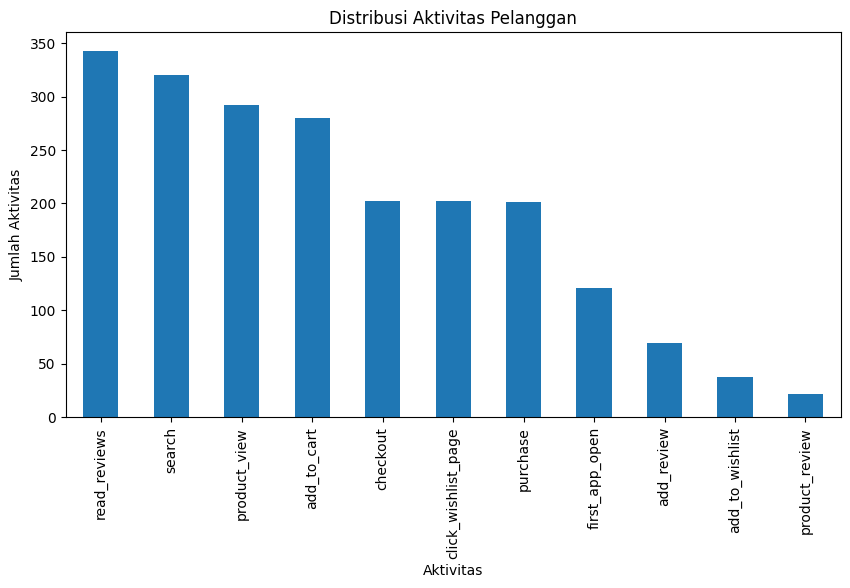

In [5]:
plt.figure(figsize=(10,5))

data_pelanggan["Action"].value_counts().plot(
    kind="bar"
)

plt.title("Distribusi Aktivitas Pelanggan")
plt.xlabel("Aktivitas")
plt.ylabel("Jumlah Aktivitas")

plt.show()

In [6]:
persentase_aktivitas = (
    data_pelanggan["Action"]
    .value_counts(normalize=True)
    * 100
)

persentase_aktivitas.round(2)

Action
read_reviews           16.41
search                 15.31
product_view           13.97
add_to_cart            13.40
checkout                9.67
click_wishlist_page     9.67
purchase                9.62
first_app_open          5.79
add_review              3.30
add_to_wishlist         1.82
product_review          1.05
Name: proportion, dtype: float64

## Insight Proses Melihat Distribusi Aktivitas Pelanggan

1. Pelanggan cenderung melakukan pencarian dan membaca ulasan sebelum membeli produk. Hal tersebut menunjukkan bahwa tidak semua pelanggan yang melihat produk akan melakukan transaksi pembelian.
2. Aktivitas menambahkan produk ke keranjang lebih tinggi dibandingkan jumlah pembelian. Hal tersebut menunjukkan bahwa masih terdapat pelanggan yang tertarik terhadap produk tetapi tidak melanjutkan proses pembelian hingga selesai.
3. Kondisi tersebut dapat menjadi peluang bagi perusahaan untuk meningkatkan konversi pembelian, misalnya dengan memberikan diskon, voucher, atau notifikasi pada keranjang belanja.

## Proses Melihat 10 Kategori Produk Terpopuler

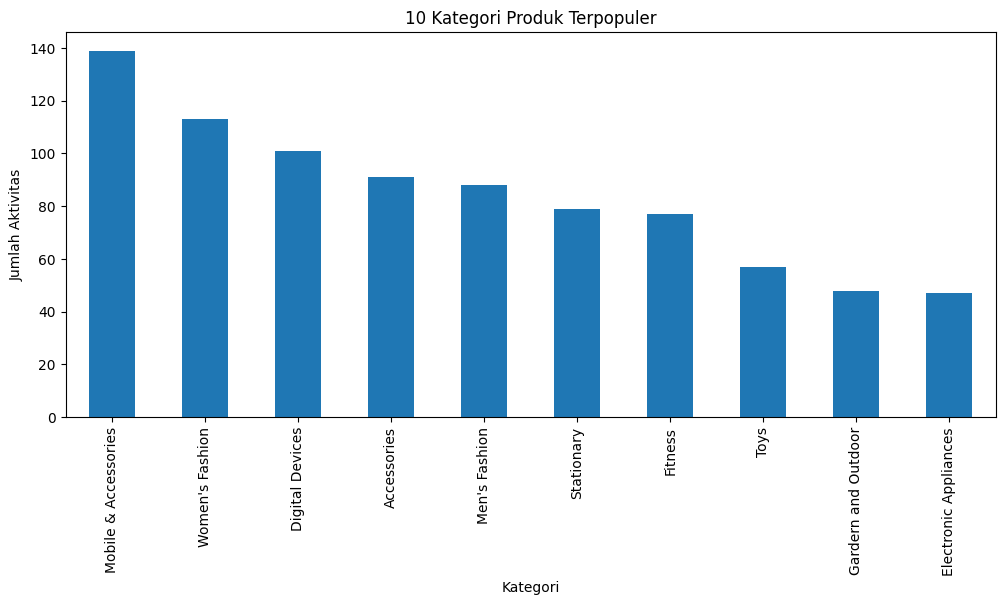

In [7]:
plt.figure(figsize=(12,5))

data_pelanggan["Category"].value_counts().head(10).plot(
    kind="bar"
)

plt.title("10 Kategori Produk Terpopuler")
plt.xlabel("Kategori")
plt.ylabel("Jumlah Aktivitas")

plt.show()

## Insight Proses Melihat 10 Kategori Produk Terpopuler

1. Kategori Mobile & Accessories merupakan kategori yang paling banyak menarik perhatian pelanggan. Hal tersebut menunjukkan bahwa produk Teknologi dan Elektronik menjadi salah satu kelompok produk yang paling sering berinteraksi dengan pelanggan.
2. Kategori Fashion, baik pria maupun wanita juga menunjukkan tingkat aktivitas yang tinggi.
3. Yang patut diperhatikan adalah Kategori Toys, Garden and Outdoor, serta Electronic Appliances memiliki tingkat aktivitas yang relatif rendah.
4. Preferensi mayoritas pelanggan cenderung terkonsentrasi pada kategori Teknologi dan Fashion sehingga kategori tersebut berpotensi menjadi kontributor utama terhadap transaksi dan pendapatan perusahaan.

## Proses Melihat 10 SubKategori Produk Terpopuler

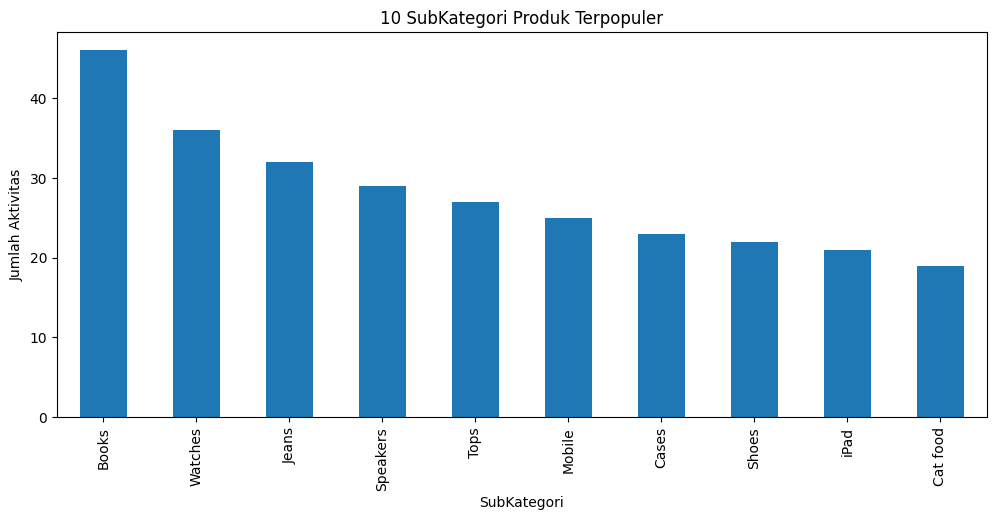

In [8]:
plt.figure(figsize=(12,5))

data_pelanggan["SubCategory"].value_counts().head(10).plot(
    kind="bar"
)

plt.title("10 SubKategori Produk Terpopuler")
plt.xlabel("SubKategori")
plt.ylabel("Jumlah Aktivitas")

plt.show()

## Insight Proses Melihat 10 SubKategori Produk Terpopuler

1. Books merupakan subkategori dengan tingkat aktivitas tertinggi yang paling sering berinteraksi dengan pelanggan.
2. Produk Fashion seperti Watches, Jeans, Tops, dan Shoes menunjukkan tingkat ketertarikan pelanggan yang cukup tinggi, dibuktikan berada di peringkat kedua tertinggi dibawah subkategori Books.
3. Produk Teknologi seperti Mobile, Speakers, iPad, dan Cases juga memiliki tingkat aktivitas yang cukup signifikan.
4. Produk gaya hidup dan kebutuhan sehari-hari menjadi kelompok produk yang paling sering berinteraksi dengan pelanggan. Hal tersebut bisa digunakan sebagai dasar dalam menentukan rekomendasi produk, prioritas promosi, dan lain sebagainya.

## Proses Melihat Distribusi Quantity

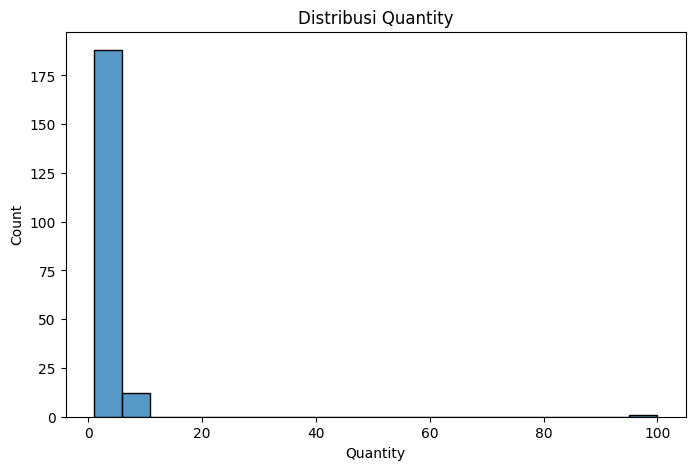

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=data_pelanggan,
    x="Quantity",
    bins=20
)

plt.title("Distribusi Quantity")
plt.show()

## Insight Proses Melihat Distribusi Quantity

1. Sebagian besar transaksi melibatkan pembelian dalam jumlah yang kecil. Hal tersebut menunjukkan bahwa terdapat variasi perilaku pembelian antar pelanggan.
2. Ditemukan indikasi outlier dengan Quantity yang mendekati 100 produk.
3. Quantity ini menjadi salah satu variable penting dalam proses modelling machine learning dan deep learning.

## Proses Melihat Distribusi Total Price

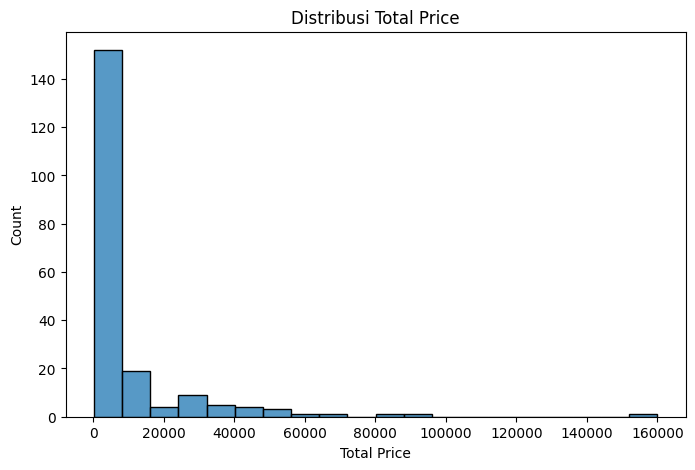

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=data_pelanggan,
    x="Total Price",
    bins=20
)

plt.title("Distribusi Total Price")
plt.show()

## Insight Proses Melihat Distribusi Total Price

1. Mayoritas pelanggan melakukan transaksi dengan nilai yang relatif rendah.
2. Distribusi Total Price tidak normal, dibuktikan dengan ditemukannya beberapa transaksi yang bernilai sangat tinggi yang dapat dikategorikan sebagai outlier.
3. Total price ini salah satu fitur yang dapat memprediksi perilaku pembelian pada pelanggan.

## Proses Analisis Funnel Aktivitas Pelanggan

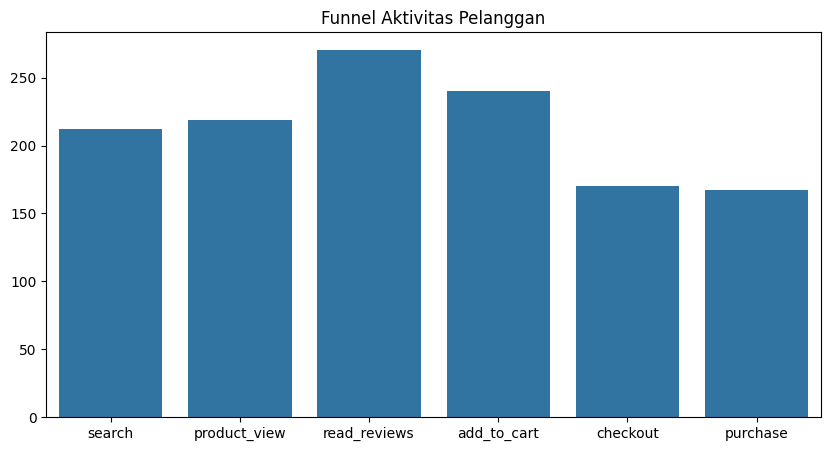

In [11]:
tahapan_funnel = [
    "search",
    "product_view",
    "read_reviews",
    "add_to_cart",
    "checkout",
    "purchase"
]

jumlah_pengguna = []

for aktivitas in tahapan_funnel:

    jumlah = (
        data_pelanggan[
            data_pelanggan["Action"] == aktivitas
        ]["User_id"]
        .nunique()
    )

    jumlah_pengguna.append(jumlah)

plt.figure(figsize=(10,5))

sns.barplot(
    x=tahapan_funnel,
    y=jumlah_pengguna
)

plt.title("Funnel Aktivitas Pelanggan")

plt.show()

## Insight Proses Analisis Funnel Aktivitas Pelanggan

1. Analisis Funnel merupakan metode analisis yang digunakan untuk melihat perjalanan pelanggan dari tahap awal hingga mencapai tujuan akhir, dalam konteks projek ini yaitu melakukan pembelian produk.
2. Aktivitas membaca ulasan produk yang paling banyak dilakukan pelanggan sebelum membeli produk dan hal tersebut berperan penting dalam proses pengambilan keputusan pada pelanggan.
3. Kehilangan pelanggan terbesar terjadi pada tahap add_to_cart menuju checkout. Hal tersebut menunjukkan bahwa terdapat peluang optimasi yang bisa dilakukan oleh perusahaan untuk meningkatkan jumlah pelanggan.

## Proses Membuat Target Pembelian

In [12]:
target_pembelian = (
    data_pelanggan
    .assign(
        target_pembelian=
        (
            data_pelanggan["Action"]
            == "purchase"
        ).astype(int)
    )
    .groupby("User_id")
    ["target_pembelian"]
    .max()
    .reset_index()
)

target_pembelian.head()

target_pembelian["target_pembelian"].value_counts()

target_pembelian["target_pembelian"].value_counts(
    normalize=True
) * 100

target_pembelian
0    58.354115
1    41.645885
Name: proportion, dtype: float64

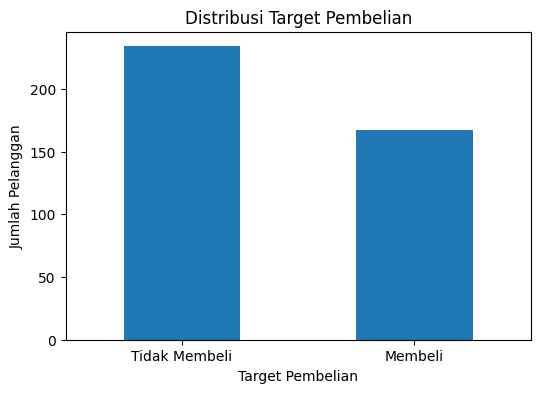

In [13]:
plt.figure(figsize=(6,4))

target_pembelian["target_pembelian"]\
.value_counts()\
.sort_index()\
.plot(kind="bar")

plt.title("Distribusi Target Pembelian")
plt.xlabel("Target Pembelian")
plt.ylabel("Jumlah Pelanggan")

plt.xticks(
    [0,1],
    ["Tidak Membeli","Membeli"],
    rotation=0
)

plt.show()

## Insight Proses Membuat Target Pembelian

1. Variabel target pembelian berhasil dibentuk sebagai target klasifikasi biner, dengan definisi label yang digunakan terdiri dari (0 = pelanggan belum pernah melakukan pembelian) dan (1 = pelanggan pernah melakukan pembelian).
2. Sebanyak 58,35% pelanggan belum pernah melakukan pembelian, sedangkan sebanyak 41,65% pelanggan sudah pernah melakukan pembelian, sehingga dapat disimpulkan bahwa distribusi target masih cukup seimbang.
3. Target pembelian ini cocok digunakan untuk mengetahui apakah terdapat seorang pelanggan yang berpotensi melakukan pembelian atau tidak berdasarkan aktivitas yang telah dilakukan pada platform e-commerce.

## Proses Membuat Fitur Jumlah Search

In [14]:
fitur_search = (
    data_pelanggan
    .assign(
        jumlah_search=
        (
            data_pelanggan["Action"]
            == "search"
        ).astype(int)
    )
    .groupby("User_id")
    ["jumlah_search"]
    .sum()
    .reset_index()
)

fitur_search.head()

,User_id,jumlah_search
0,51443820326,1
1,51448162784,2
2,51455512201,2
3,51462598385,4
4,51463622150,4


In [15]:
fitur_search["jumlah_search"].describe()

count    401.000000
mean       0.798005
std        1.063765
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        6.000000
Name: jumlah_search, dtype: float64

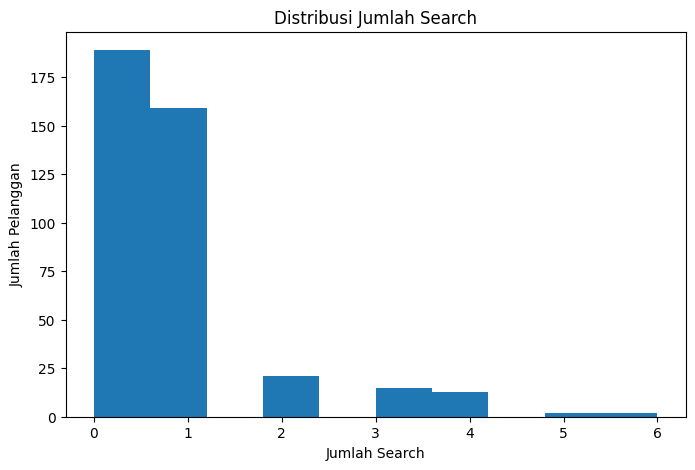

In [16]:
plt.figure(figsize=(8,5))

plt.hist(
    fitur_search["jumlah_search"],
    bins=10
)

plt.title("Distribusi Jumlah Search")
plt.xlabel("Jumlah Search")
plt.ylabel("Jumlah Pelanggan")

plt.show()

## Insight Proses Membuat Fitur Jumlah Search

1. Fitur Jumlah Search berhasil dibentuk melalui proses agregasi aktivitas pencarian produk yang dilakukan oleh setiap pelanggan selama berinteraksi dengan platform e-commerce.
2. Dataset terdiri dari 401 pelanggan unik, mayoritas pelanggan hanya melakukan pencarian sebanyak 0–1 kali.
3. Sebanyak kurang lebih 75% pelanggan melakukan pencarian maksimal satu kali dan juga terdapat sebagian kecil pelanggan yang melakukan pencarian hingga 6 kali.
4. Aktivitas pencarian tersebut menunjukkan adanya variasi perilaku pada pelanggan dalam mengeksplorasi suatu produk.

## Proses Membuat Fitur Jumlah Lihat Produk

In [17]:
fitur_lihat_produk = (
    data_pelanggan
    .assign(
        jumlah_lihat_produk=
        (
            data_pelanggan["Action"]
            == "product_view"
        ).astype(int)
    )
    .groupby("User_id")
    ["jumlah_lihat_produk"]
    .sum()
    .reset_index()
)

fitur_lihat_produk.head()

,User_id,jumlah_lihat_produk
0,51443820326,0
1,51448162784,1
2,51455512201,2
3,51462598385,4
4,51463622150,2


In [18]:
fitur_lihat_produk["jumlah_lihat_produk"].describe()

count    401.000000
mean       0.728180
std        0.915658
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        6.000000
Name: jumlah_lihat_produk, dtype: float64

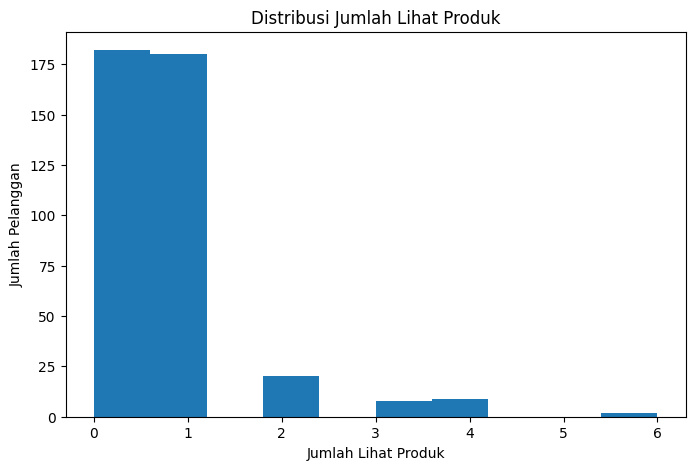

In [19]:
plt.figure(figsize=(8,5))

plt.hist(
    fitur_lihat_produk["jumlah_lihat_produk"],
    bins=10
)

plt.title("Distribusi Jumlah Lihat Produk")
plt.xlabel("Jumlah Lihat Produk")
plt.ylabel("Jumlah Pelanggan")

plt.show()

## Insight Proses Membuat Fitur Jumlah Lihat Produk

1. Fitur Jumlah Lihat Produk berhasil dibentuk melalui proses agregasi aktivitas melihat produk (product_view) yang dilakukan oleh setiap pelanggan selama berinteraksi dengan platform e-commerce.
2. Mayoritas pelanggan hanya melihat produk sebanyak 0–1 kali. Terdapat juga sebagian kecil dari pelanggan yang sangat aktif melihat produk hingga 6 kali.
3. Temuan ini menunjukkan bahwa sebagian besar pelanggan belum melakukan eksplorasi produk secara mendalam sebelum melakukan aktivitas lainnya.

## Proses Membuat Fitur Jumlah Baca Review

In [20]:
fitur_baca_review = (
    data_pelanggan
    .assign(
        jumlah_baca_review=
        (
            data_pelanggan["Action"]
            == "read_reviews"
        ).astype(int)
    )
    .groupby("User_id")
    ["jumlah_baca_review"]
    .sum()
    .reset_index()
)

fitur_baca_review.head()

,User_id,jumlah_baca_review
0,51443820326,0
1,51448162784,2
2,51455512201,2
3,51462598385,1
4,51463622150,1


In [21]:
fitur_baca_review["jumlah_baca_review"].describe()

count    401.000000
mean       0.855362
std        0.817941
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        6.000000
Name: jumlah_baca_review, dtype: float64

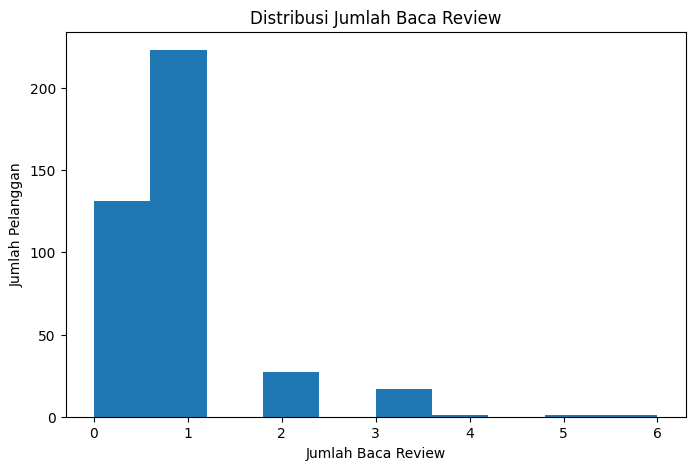

In [22]:
plt.figure(figsize=(8,5))

plt.hist(
    fitur_baca_review["jumlah_baca_review"],
    bins=10
)

plt.title("Distribusi Jumlah Baca Review")
plt.xlabel("Jumlah Baca Review")
plt.ylabel("Jumlah Pelanggan")

plt.show()

## Insight Proses Membuat Fitur Jumlah Baca Review

1. Fitur Jumlah Baca Review berhasil dibentuk dari aktivitas pelanggan dalam membaca ulasan produk.
2. Mayoritas pelanggan hanya membaca review sebanyak 0–1 kali.
3. Membaca review atau ulasan memiliki aktivitas yang lebih tinggi dibandingkan aktivitas pencarian dan melihat produk pada dataset ini.

## Proses Membuat Fitur Jumlah Keranjang

In [23]:
fitur_keranjang = (
    data_pelanggan
    .assign(
        jumlah_keranjang=
        (
            data_pelanggan["Action"]
            == "add_to_cart"
        ).astype(int)
    )
    .groupby("User_id")
    ["jumlah_keranjang"]
    .sum()
    .reset_index()
)

fitur_keranjang.head()

,User_id,jumlah_keranjang
0,51443820326,0
1,51448162784,2
2,51455512201,1
3,51462598385,2
4,51463622150,2


In [24]:
fitur_keranjang["jumlah_keranjang"].describe()

count    401.000000
mean       0.698254
std        0.652857
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        3.000000
Name: jumlah_keranjang, dtype: float64

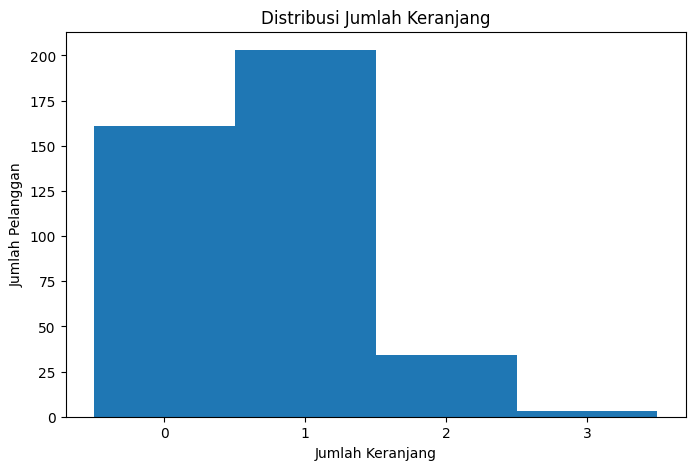

In [25]:
plt.figure(figsize=(8,5))

plt.hist(
    fitur_keranjang["jumlah_keranjang"],
    bins=[-0.5,0.5,1.5,2.5,3.5]
)

plt.xticks([0,1,2,3])

plt.title("Distribusi Jumlah Keranjang")
plt.xlabel("Jumlah Keranjang")
plt.ylabel("Jumlah Pelanggan")

plt.show()

## Insight Proses Membuat Fitur Jumlah Keranjang

1. Fitur Jumlah Keranjang berhasil dibentuk dari aktivitas add_to_cart.
2. Mayoritas pelanggan hanya melakukan aktivitas add_to_cart sebanyak 0–1 kali. Pelanggan yang melakukan pembelian memiliki rata-rata aktivitas menambahkan produk ke keranjang hampir 3 kali lebih tinggi dibanding pelanggan yang tidak membeli.

## Proses Membuat Fitur Jumlah Checkout

In [26]:
fitur_checkout = (
    data_pelanggan
    .assign(
        jumlah_checkout=
        (
            data_pelanggan["Action"]
            == "checkout"
        ).astype(int)
    )
    .groupby("User_id")
    ["jumlah_checkout"]
    .sum()
    .reset_index()
)

fitur_checkout.head()

,User_id,jumlah_checkout
0,51443820326,0
1,51448162784,2
2,51455512201,1
3,51462598385,2
4,51463622150,2


In [27]:
fitur_checkout["jumlah_checkout"].describe()

count    401.000000
mean       0.503741
std        0.648545
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        3.000000
Name: jumlah_checkout, dtype: float64

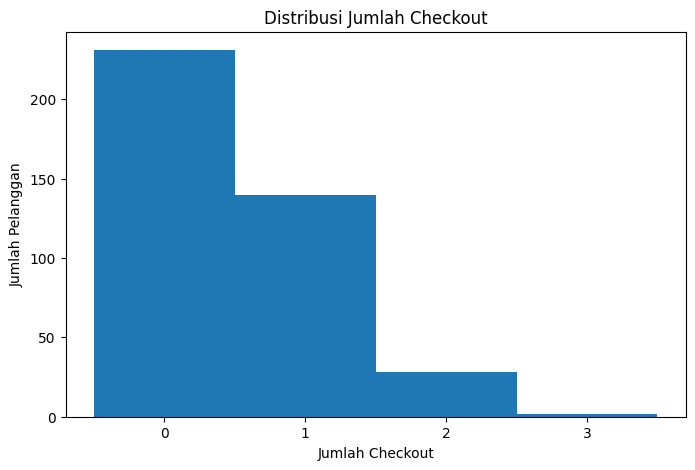

In [28]:
plt.figure(figsize=(8,5))

plt.hist(
    fitur_checkout["jumlah_checkout"],
    bins=[-0.5,0.5,1.5,2.5,3.5]
)

plt.xticks([0,1,2,3])

plt.title("Distribusi Jumlah Checkout")
plt.xlabel("Jumlah Checkout")
plt.ylabel("Jumlah Pelanggan")

plt.show()

## Insight Proses Membuat Fitur Jumlah Checkout

1. Fitur Jumlah Checkout berhasil dibentuk dari aktivitas checkout pelanggan.
2. Pelanggan yang melakukan pembelian memiliki rata-rata aktivitas checkout sebesar 1,186 kali, sedangkan pelanggan yang tidak membeli hanya sebesar 0,017 kali. Hal tersebut menunjukkan bahwa aktivitas checkout memiliki hubungan yang berbanding lurus terhadap target pembelian.

## Proses Menggabungkan Semua Fitur

In [29]:
data_model = target_pembelian.copy()

data_model = data_model.merge(
    fitur_search,
    on="User_id",
    how="left"
)

data_model = data_model.merge(
    fitur_lihat_produk,
    on="User_id",
    how="left"
)

data_model = data_model.merge(
    fitur_baca_review,
    on="User_id",
    how="left"
)

data_model = data_model.merge(
    fitur_keranjang,
    on="User_id",
    how="left"
)

data_model = data_model.merge(
    fitur_checkout,
    on="User_id",
    how="left"
)

data_model.head()

,User_id,target_pembelian,jumlah_search,jumlah_lihat_produk,jumlah_baca_review,jumlah_keranjang,jumlah_checkout
0,51443820326,0,1,0,0,0,0
1,51448162784,1,2,1,2,2,2
2,51455512201,1,2,2,2,1,1
3,51462598385,1,4,4,1,2,2
4,51463622150,1,4,2,1,2,2


## Insight Proses Menggabungkan Semua Fitur

a. Dataset akhir telah memiliki target dan fitur yang lengkap untuk proses pemodelan, seperti di bawah ini:

1 Variabel Target:
- target_pembelian

5 Variabel Fitur:
- jumlah_search
- jumlah_lihat_produk
- jumlah_baca_review
- jumlah_keranjang
- jumlah_checkout

b. Fitur yang dibentuk menggambarkan perjalanan pelanggan mulai dari tahap eksplorasi hingga tahap transaksi, seperti di bawah ini:

Jumlah Search → Jumlah Lihat Produk → Jumlah Baca Review → Jumlah Keranjang → Jumlah Checkout → Target Pembelian

Nantinya model dapat mempelajari hubungan antara aktivitas pelanggan dan keputusan pembelian yang dilakukan.

c. Fitur yang dibentuk telah mengubah data aktivitas mentah menjadi data numerik, karena sebelum dilakukan feature engineering, data aktivitas pelanggan masih berupa:

- search
- product_view
- read_reviews
- add_to_cart
- checkout



## Proses Analisis Korelasi Antar Fitur

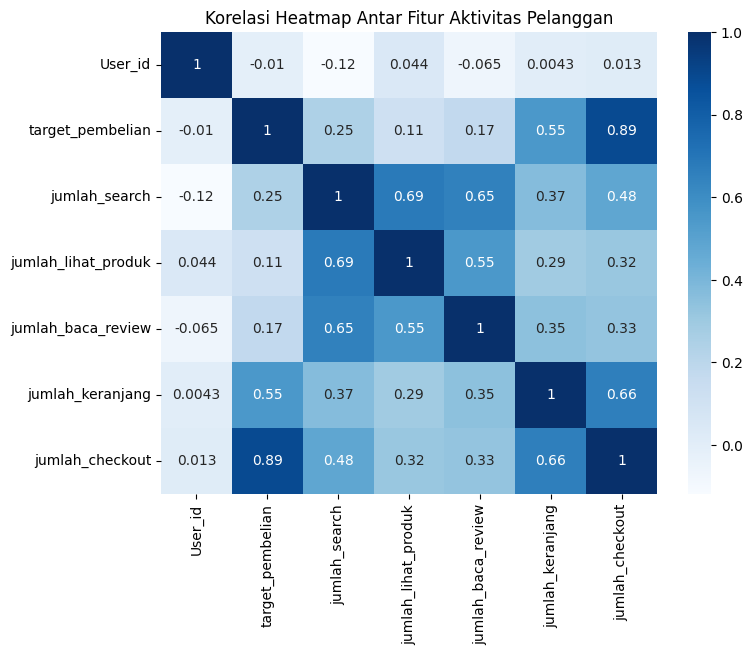

In [30]:
plt.figure(figsize=(8,6))

sns.heatmap(
    data_model.corr(
        numeric_only=True
    ),
    annot=True,
    cmap="Blues"
)

plt.title(
    "Korelasi Heatmap Antar Fitur Aktivitas Pelanggan"
)

plt.show()

## Insight Proses Analisis Korelasi Antar Fitur

1. Analisis korelasi ini dilakukan untuk mengidentifikasi kekuatan hubungan antar fitur hasil proses Feature Engineering serta hubungan masing-masing fitur terhadap target pembelian pelanggan.
2. Fitur jumlah_checkout memiliki korelasi positif paling tinggi terhadap fitur target_pembelian dengan nilai korelasi sebesar 0,89. Hal tersebut menunjukkan bahwa aktivitas checkout merupakan indikator paling kuat dalam membedakan pelanggan yang melakukan pembelian dan yang tidak melakukan pembelian.
3. Fitur jumlah_keranjang memiliki korelasi positif sebesar 0,55 terhadap target pembelian. Nilai tersebut menunjukkan bahwa pelanggan yang lebih sering menambahkan produk ke keranjang cenderung mempunyai peluang yang lebih besar untuk melakukan pembelian.
4. Fitur jumlah_search memiliki korelasi sebesar 0,25 terhadap target pembelian, sedangkan jumlah_lihat_produk dan jumlah_baca_review masing-masing memiliki korelasi sebesar 0,11 dan 0,17. Hal tersebut mengindikasikan bahwa aktivitas pencarian, melihat produk, dan membaca review masih berada pada tahap eksplorasi sehingga pengaruh terhadap keputusan pembelian relatif lebih rendah dibandingkan aktivitas keranjang dan checkout.
5. Terdapat hubungan yang cukup kuat antara:
- jumlah_search ↔ jumlah_lihat_produk = 0,69
- jumlah_search ↔ jumlah_baca_review = 0,65
- jumlah_keranjang ↔ jumlah_checkout = 0,66
Hal tersebut menunjukkan bahwa pola aktivitas pelanggan yang masuk akal atau logis dimana pelanggan yang aktif mencari produk cenderung melihat produk dan membaca review, sedangkan pelanggan yang menambahkan produk ke keranjang cenderung melanjutkan ke proses checkout.

## Proses Menyimpan Dataset Hasil Feature Engineering

In [31]:
data_model.to_csv(
    "../Data/data_model_final.csv",
    index=False
)